In [7]:
import pandas as pd
import nltk
import string
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [8]:
# Download stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [10]:
df = pd.read_csv("tickets.csv", encoding='latin1')

# -------------------------
# SELECT IMPORTANT COLUMNS
# -------------------------
df = df[[
    'Ticket Subject',
    'Ticket Description',
    'Ticket Type',
    'Ticket Priority',
    'Ticket Status',
    'Ticket Channel',
    'Customer Satisfaction Rating'
]]

# Remove missing values
df = df.dropna()

print("✅ Dataset Loaded Successfully")

✅ Dataset Loaded Successfully


In [12]:
df['text'] = df['Ticket Subject'] + " " + df['Ticket Description']

# Rename columns
df = df.rename(columns={
    'Ticket Type': 'category',
    'Ticket Priority': 'priority'
})

✅ Text Cleaning Completed


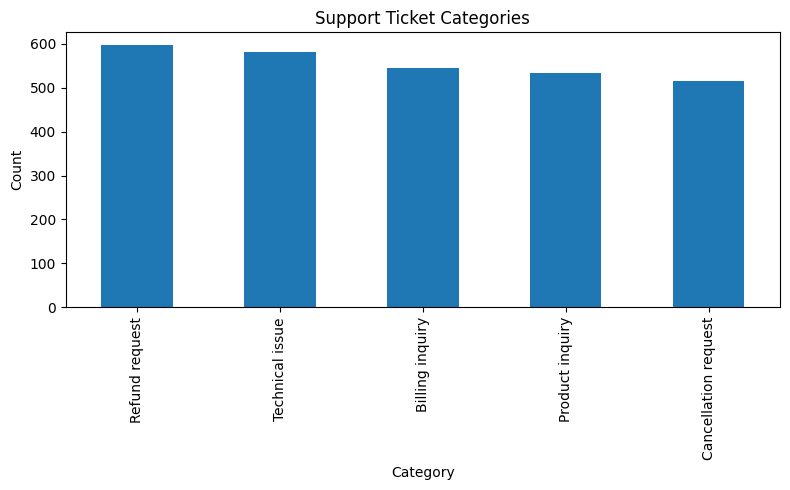

In [13]:
def clean_text(text):
    text = text.lower()

    # Remove punctuation
    text = "".join([c for c in text if c not in string.punctuation])

    # Remove stopwords
    words = text.split()
    words = [w for w in words if w not in stopwords.words('english')]

    return " ".join(words)

# Apply cleaning
df['clean_text'] = df['text'].apply(clean_text)

print("✅ Text Cleaning Completed")

# -------------------------
# VISUALIZATION 1
# TICKET CATEGORY COUNT
# -------------------------
plt.figure(figsize=(8,5))
df['category'].value_counts().plot(kind='bar')

plt.title("Support Ticket Categories")
plt.xlabel("Category")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("ticket_categories.png")
plt.show()


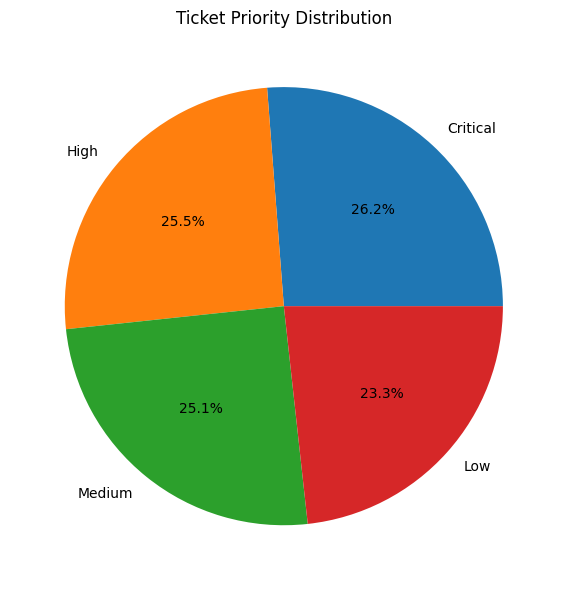

In [14]:
plt.figure(figsize=(6,6))
df['priority'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Ticket Priority Distribution")
plt.ylabel("")

plt.tight_layout()
plt.savefig("priority_distribution.png")
plt.show()

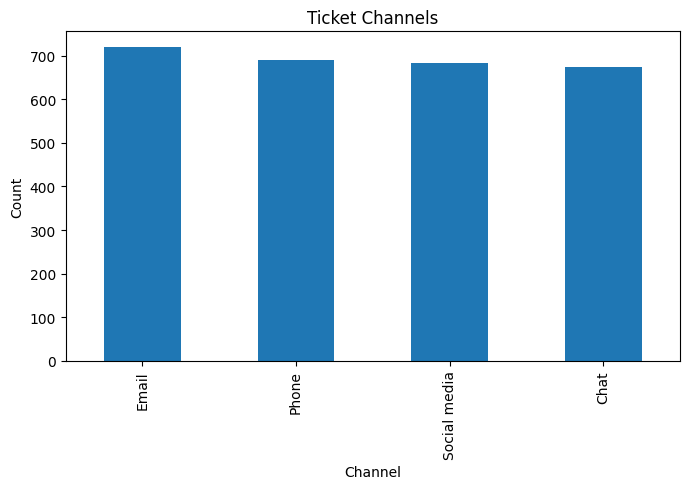

In [15]:
plt.figure(figsize=(7,5))
df['Ticket Channel'].value_counts().plot(kind='bar')

plt.title("Ticket Channels")
plt.xlabel("Channel")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("ticket_channels.png")
plt.show()

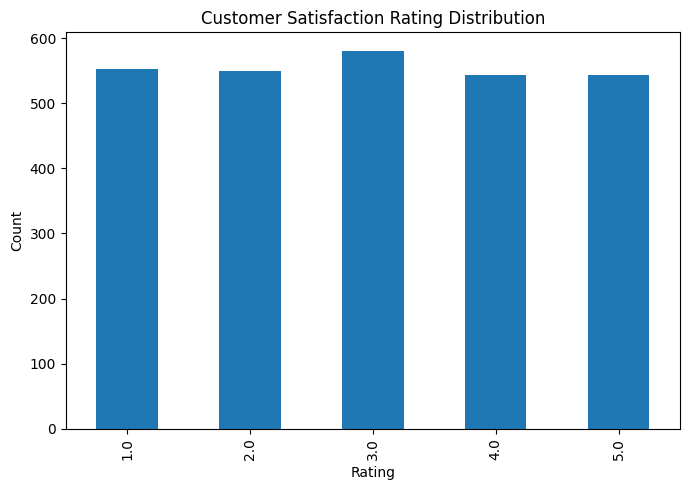

In [19]:
plt.figure(figsize=(7,5))

df['Customer Satisfaction Rating'].value_counts().sort_index().plot(kind='bar')

plt.title("Customer Satisfaction Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("customer_satisfaction.png")
plt.show()

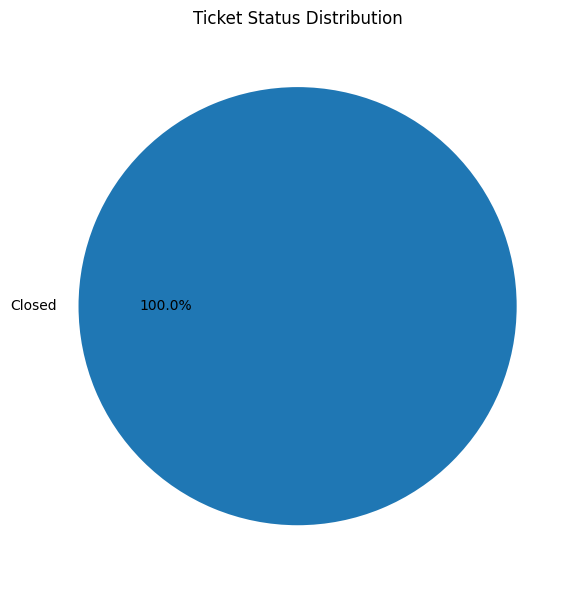

In [ ]:
plt.figure(figsize=(6,6))
df['Customer Satisfaction Rating'].value_counts().sort_index().plot(kind='bar')
plt.title("Ticket Status Distribution")
plt.ylabel("")

plt.tight_layout()
plt.savefig("ticket_status.png")
plt.show()

In [ ]:
y_category = df['category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_category, test_size=0.2, random_state=42
)

model_cat = LogisticRegression(max_iter=1000)

model_cat.fit(X_train, y_train)

pred_cat = model_cat.predict(X_test)

print("\n📊 Category Classification Report:\n")
print(classification_report(y_test, pred_cat))

cat_accuracy = accuracy_score(y_test, pred_cat)

print("✅ Category Accuracy:", cat_accuracy)

In [ ]:
cm = confusion_matrix(y_test, pred_cat, labels=model_cat.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model_cat.classes_
)

fig, ax = plt.subplots(figsize=(8,6))
disp.plot(ax=ax)

plt.title("Category Confusion Matrix")

plt.savefig("confusion_matrix.png")
plt.show()

In [ ]:
y_priority = df['priority']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y_priority, test_size=0.2, random_state=42
)

model_pri = LogisticRegression(max_iter=1000)

model_pri.fit(X_train2, y_train2)

pred_pri = model_pri.predict(X_test2)

print("\n📊 Priority Classification Report:\n")
print(classification_report(y_test2, pred_pri))

pri_accuracy = accuracy_score(y_test2, pred_pri)

print("✅ Priority Accuracy:", pri_accuracy)

In [ ]:
models = ['Category Model', 'Priority Model']
accuracies = [cat_accuracy, pri_accuracy]

plt.figure(figsize=(6,5))
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.ylim(0,1)

plt.tight_layout()
plt.savefig("accuracy_comparison.png")
plt.show()

In [ ]:
sample_ticket = [
    "Payment failed and amount deducted from my bank account"
]

sample_clean = [clean_text(text) for text in sample_ticket]

sample_vector = vectorizer.transform(sample_clean)

category_prediction = model_cat.predict(sample_vector)
priority_prediction = model_pri.predict(sample_vector)

print("\n🔍 SAMPLE PREDICTION")
print("Predicted Category:", category_prediction)
print("Predicted Priority:", priority_prediction)

# -------------------------
# BUSINESS INSIGHTS
# -------------------------
print("\n📌 BUSINESS INSIGHTS")

print("""
1. The system automatically categorizes support tickets.
2. High-priority issues can be identified faster.
3. Support teams can reduce manual sorting effort.
4. Businesses can improve response efficiency.
5. Customer satisfaction can improve through faster resolutions.
""")

print("\n✅ TASK COMPLETED SUCCESSFULLY")